# Feature Scaling

Most ML algorithms are sensitive to the scale of numerical features. A feature measured in thousands can dominate a feature measured in single digits, even if the latter is more informative.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import warnings
warnings.filterwarnings('ignore')

df = sns.load_dataset('titanic')
num_df = df[['age', 'fare', 'pclass', 'sibsp', 'parch']].dropna().copy()
print("Numerical feature ranges before scaling:")
print(num_df.describe().loc[['min', 'max']].round(2))

Numerical feature ranges before scaling:
       age    fare  pclass  sibsp  parch
min   0.42    0.00     1.0    0.0    0.0
max  80.00  512.33     3.0    5.0    6.0


## Why Scaling Matters

Algorithms that rely on distance or gradient updates are heavily affected by feature scale:

| Algorithm | Needs scaling? |
|---|---|
| Linear Regression | Yes (gradient descent converges faster) |
| Logistic Regression | Yes |
| KNN | Yes (distance-based) |
| SVM | Yes |
| PCA | Yes (preserves variance direction) |
| Decision Tree | No (split-based, order preserved) |
| Random Forest | No |
| XGBoost | No |

---
## Method 1: Min-Max Normalisation

Rescales every value into the range **[0, 1]**:

$$x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

- Preserves the shape of the distribution exactly
- Sensitive to outliers (an extreme max will compress all other values near 0)
- Best when you know the feature has a bounded range and no severe outliers

In [2]:
minmax = MinMaxScaler()
num_minmax = pd.DataFrame(
    minmax.fit_transform(num_df),
    columns=num_df.columns
)

print("After Min-Max scaling — range of each feature:")
print(num_minmax.describe().loc[['min', 'max']].round(4))

After Min-Max scaling — range of each feature:
     age  fare  pclass  sibsp  parch
min  0.0   0.0     0.0    0.0    0.0
max  1.0   1.0     1.0    1.0    1.0


---
## Method 2: Z-Score Standardisation

Transforms data to have **mean = 0** and **std = 1**:

$$x' = \frac{x - \mu}{\sigma}$$

- The resulting values are z-scores (how many std devs from the mean)
- More robust to outliers than Min-Max (no fixed bounds — extreme values don't compress others)
- Best for algorithms that assume normally distributed features (linear models, PCA)

In [3]:
std_scaler = StandardScaler()
num_std = pd.DataFrame(
    std_scaler.fit_transform(num_df),
    columns=num_df.columns
)

print("After Z-score standardisation — mean and std:")
print(num_std.describe().loc[['mean', 'std']].round(4))

After Z-score standardisation — mean and std:
         age    fare  pclass   sibsp   parch
mean  0.0000 -0.0000 -0.0000 -0.0000 -0.0000
std   1.0007  1.0007  1.0007  1.0007  1.0007


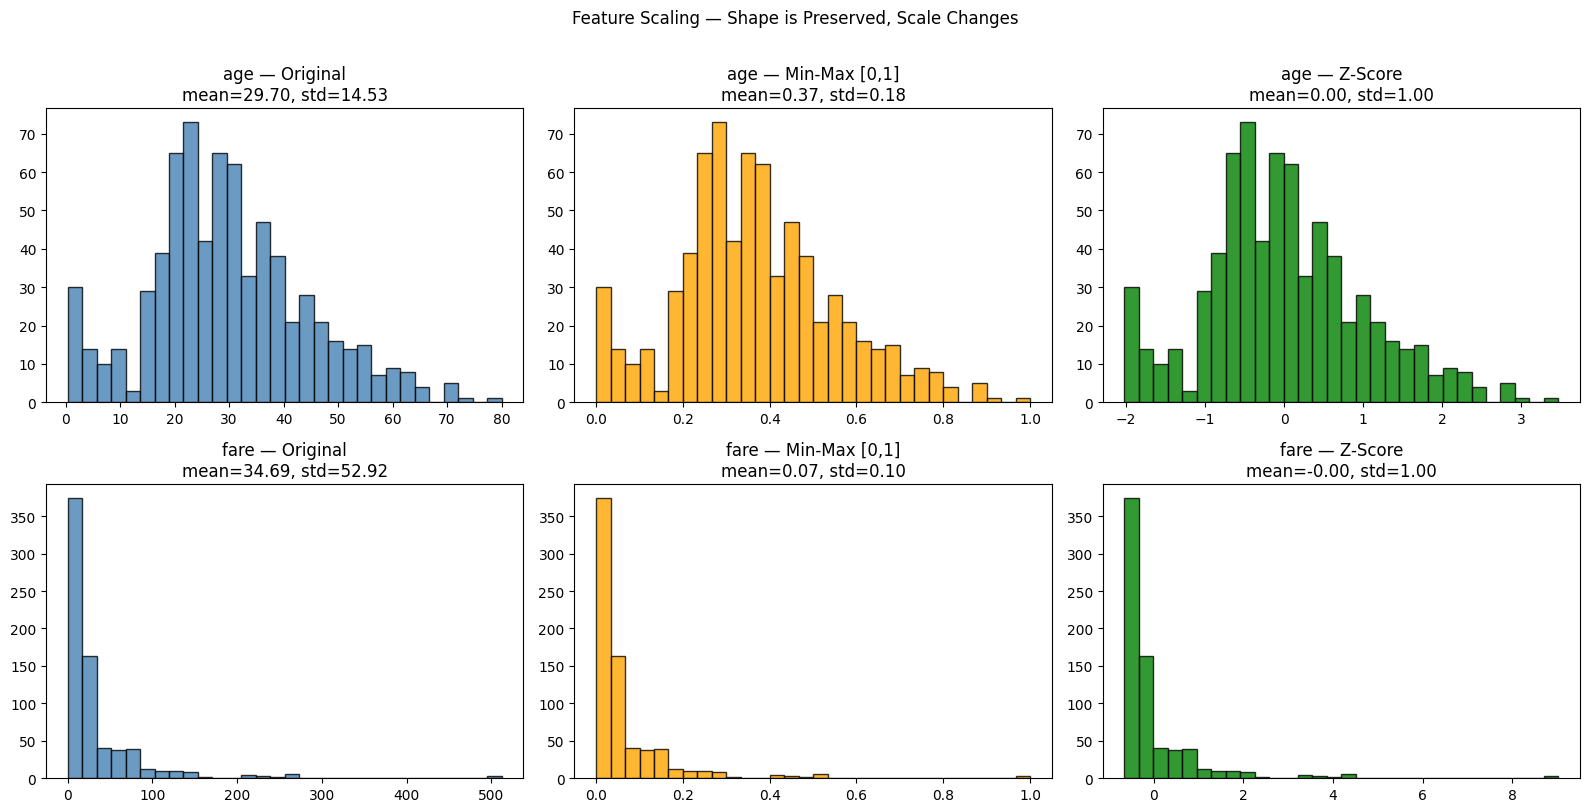

In [4]:
# Visual comparison: original vs min-max vs z-score for 'age' and 'fare'
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for row, col in enumerate(['age', 'fare']):
    for ax, (data, title, color) in zip(
        axes[row],
        [
            (num_df[col],       f'{col} — Original',     'steelblue'),
            (num_minmax[col],   f'{col} — Min-Max [0,1]','orange'),
            (num_std[col],      f'{col} — Z-Score',      'green')
        ]
    ):
        ax.hist(data, bins=30, color=color, edgecolor='black', alpha=0.8)
        ax.set_title(f'{title}\nmean={data.mean():.2f}, std={data.std():.2f}')

plt.suptitle('Feature Scaling — Shape is Preserved, Scale Changes', y=1.01)
plt.tight_layout()
plt.show()

## The Critical Rule: Fit on Train, Transform on Both

Always compute the scaler parameters (min, max, mean, std) from the **training set only**. Apply those parameters to both train and test.

Fitting on the full dataset leaks test set statistics into training — a form of **data leakage**.

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(num_df, test_size=0.2, random_state=42)

# Correct workflow
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)         # transform only on test

print("Train mean after scaling:", X_train_scaled.mean(axis=0).round(4))
print("Test  mean after scaling:", X_test_scaled.mean(axis=0).round(4))
print()
print("Test mean is non-zero — that's correct: scaler was fit on train, not test.")

Train mean after scaling: [ 0.  0.  0. -0. -0.]
Test  mean after scaling: [-0.1078 -0.0387  0.0851  0.1655 -0.0473]

Test mean is non-zero — that's correct: scaler was fit on train, not test.


## Choosing a Scaling Method

| Situation | Use |
|---|---|
| Need output in [0, 1]; no severe outliers | Min-Max |
| Algorithm assumes Gaussian (linear models, PCA) | Z-score |
| Outliers are present | Z-score (less distorted) |
| Tree-based models | Neither needed |

**Key takeaway**: scaling changes the *range*, not the *shape* or *rank order* of values.